In [1]:
import astroquery
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

In [2]:
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source" #remove table size warnings

In [12]:
#Function to clean data (method adapted from Babusiaux 2018, changed to work w/ 3rd iteration of Gaia Data)
def clean_gaia_data(data_table):
    # boolean array (mask) that starts as all True
    mask = np.ones(len(data_table), dtype=bool)
    mask &= (data_table['parallax_over_error'] > 10) #This filter removes all data that has a parallax uncertainy > 10%
    # In Data Release 3, these are combined into the RUWE score. An optimal RUWE is 1.0 however Bommert 2020 says anything <1.4 is acceptable
    mask &= (data_table['ruwe'] < 1.4)
    #Next I removed stars where the brightness does not match the opbserved temp (happens w. binaries/overcrowded stars, etc.)
    #Babusiaux does this with a curve defined as Equation 1
    # removing outliers in 'phot_bp_rp_excess_factor' (found outside of 1.0-1.3 range) is effectively the same
    bp_rp = data_table['bp_rp']
    excess_factor = data_table['phot_bp_rp_excess_factor']
    #I created a simplified version of the curve from teh paper
    # 1.0 + 0.015*color^2  <  Factor  <  1.3 + 0.06*color^2
    lower_bound = 1.0 + 0.015 * bp_rp**2
    upper_bound = 1.3 + 0.06 * bp_rp**2
   
    mask &= (excess_factor > lower_bound) & (excess_factor < upper_bound)
    
    # Applying the mask
    cleaned_data = data_table[mask]
    
    print(f"Original rows: {len(data_table)}")
    print(f"Cleaned rows:  {len(cleaned_data)}")
    return cleaned_data

In [17]:
#querying esa gaia database
query = """
SELECT TOP 2000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 66.75, 15.87, 5))
AND parallax > 10  
"""
# Hyades is only ~45pc away, so parallax must be pretty large
job = Gaia.launch_job_async(query)
hyades_raw = job.get_results()
hyades_clean = clean_gaia_data(hyades_raw)

INFO: Query finished. [astroquery.utils.tap.core]
Original rows: 953
Cleaned rows:  657


In [15]:
# Iterative Algorithm that utilizes sigma-clipping in Proper Motion and Parallax space.

def iterative_cluster_selection(data, sigma=3.0, max_iters=10):

    # boolean mask to track which stars are 'members'
    mask = np.ones(len(data), dtype=bool)
    
    # loop to refine selection
    for i in range(max_iters):
        # Selects the current working set of stars
        current_members = data[mask]
        
        # Calculates the center (median) and spread (std) of this set
        med_pmra = np.median(current_members['pmra'])
        std_pmra = np.std(current_members['pmra'])
        
        med_pmdec = np.median(current_members['pmdec'])
        std_pmdec = np.std(current_members['pmdec'])
        
        med_plx = np.median(current_members['parallax'])
        std_plx = np.std(current_members['parallax'])
        
        # new mask for the next iteration
        # A star is a member if it is within 'sigma' standard deviations of the center in ALL three coordinates.
        new_mask = (
            (np.abs(data['pmra'] - med_pmra) < sigma * std_pmra) &
            (np.abs(data['pmdec'] - med_pmdec) < sigma * std_pmdec) &
            (np.abs(data['parallax'] - med_plx) < sigma * std_plx)
        )
        
        # Once the mask no longer changes stop
        n_old = np.sum(mask)
        n_new = np.sum(new_mask)
        print(f"Iteration {i+1}: Kept {n_new} stars (was {n_old})")
        
        if np.array_equal(mask, new_mask):
            print("Converged!")
            break
            
        # Update the mask for the next loop
        mask = new_mask
        
    return data[mask]

hyades_members = iterative_cluster_selection(hyades_clean, sigma=2.8) # sigma = 2.8 gave good results when comparing multiple values

Iteration 1: Kept 629 stars (was 657)
Iteration 2: Kept 602 stars (was 629)
Iteration 3: Kept 588 stars (was 602)
Iteration 4: Kept 579 stars (was 588)
Iteration 5: Kept 571 stars (was 579)
Iteration 6: Kept 563 stars (was 571)
Iteration 7: Kept 557 stars (was 563)
Iteration 8: Kept 553 stars (was 557)
Iteration 9: Kept 550 stars (was 553)
Iteration 10: Kept 550 stars (was 550)
Converged!


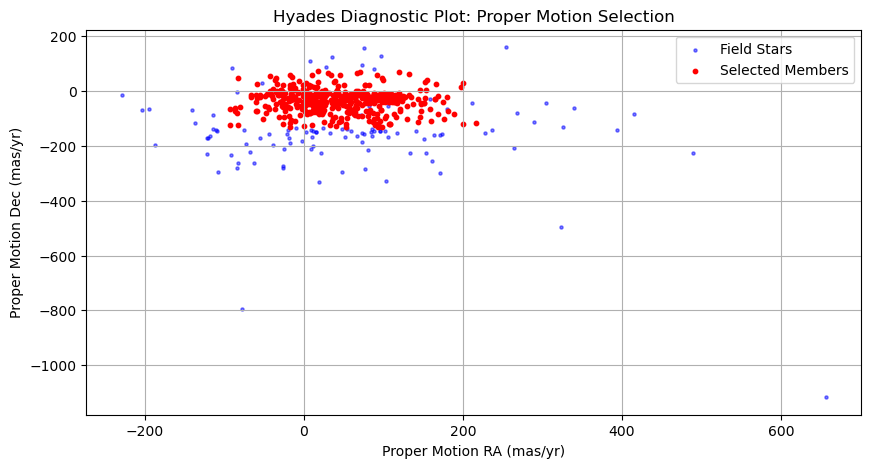

In [13]:
plt.figure(figsize=(10, 5))

# Plot all stars (Background)
plt.scatter(hyades_clean['pmra'], hyades_clean['pmdec'], 
            s=5, color='blue', alpha=0.5, label='Field Stars')

# Plot selected members (Cluster)
plt.scatter(hyades_members['pmra'], hyades_members['pmdec'], 
            s=10, color='red', label='Selected Members')

plt.xlabel('Proper Motion RA (mas/yr)')
plt.ylabel('Proper Motion Dec (mas/yr)')
plt.title('Hyades Diagnostic Plot: Proper Motion Selection')
plt.legend()
plt.grid(True)
plt.show()

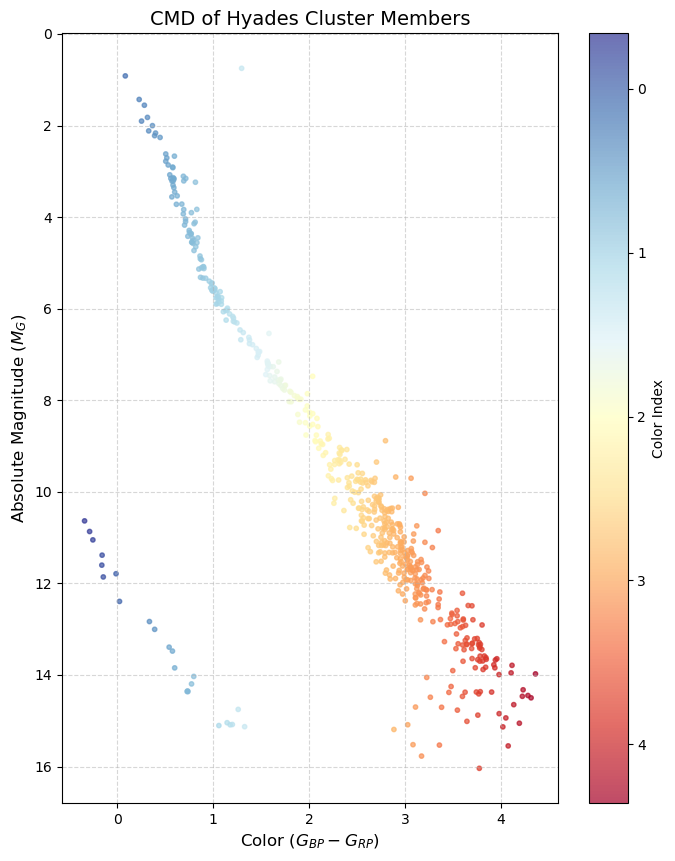

In [16]:
# to find the distance -> Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / hyades_members['parallax']

# Absolute Magnitude -> M = m - 5 * log10(d) + 5
abs_mag_g = hyades_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Gaia provides 'bp_rp' directly -> (Blue_mag - Red_mag)
color = hyades_members['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Hyades Cluster Members', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()